# Soal Nomor 3 — Root of Equations

**Masalah:** Gudang maksimal menyimpan 25.000 tas/bulan. Cari kapan produksi melebihi 25.000, lalu tentukan kapan harus mulai bangun gudang baru (butuh 13 bulan konstruksi).

**Model:** Model polinomial derajat 3 dari Soal 1.

**Metode:** Bisection Method

**Alasan:** Bisection Method dipilih karena fungsi polinomial bersifat kontinu sehingga Teorema Nilai Tengah terpenuhi. Metode ini konvergen terjamin (tidak seperti Newton-Raphson yang butuh tebakan awal bagus), mudah diimplementasikan, dan akurasinya bisa diatur lewat toleransi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('aol_data.xlsx')
x = np.arange(1, 145)
y = data.values[0]

a3, a2, a1, a0 = np.polyfit(x, y, 3)
model_polinomial = np.poly1d([a3, a2, a1, a0])

print(f"Model: P(t) = {a3:.3f}t\u00b3 + {a2:.3f}t\u00b2 + {a1:.3f}t + {a0:.3f}")

Model: P(t) = 0.004t³ + -0.134t² + 47.224t + 1748.507


## Bisection Method

**Definisi fungsi:** Fungsi f(t) didefinisikan sebagai selisih antara model produksi P(t) dengan kapasitas gudang 25.000. Akar dari fungsi ini (f(t) = 0) adalah waktu ketika produksi mencapai kapasitas maksimal.

**Cara kerja:**
1. Tentukan interval awal [a, b] di mana f(a) dan f(b) memiliki tanda berlawanan
2. Hitung titik tengah c = (a + b)/2
3. Jika f(c) mendekati 0 dalam toleransi, stop
4. Jika tanda f(c) sama dengan f(a), geser a = c; jika sama dengan f(b), geser b = c
5. Ulang hingga konvergen

In [3]:
kapasitas = 25000

def f(t):
    return a3*t**3 + a2*t**2 + a1*t + a0 - kapasitas

In [4]:
kiri = 144.0   # Data terakhir
kanan = kiri + 1

while f(kanan) < 0:
    kanan += 1

akurasi = 0.001

iter = 0
while True:
    iter += 1
    
    tengah = (kiri + kanan) / 2
    
    f_tengah = f(tengah)

    if abs(f_tengah) <= akurasi:
        print(f"\nKONVERGEN setelah {iter} langkah!")
        print(f"f(t) = {f_tengah:.3f} (sudah mendekati 0)")
        t_hasil = tengah
        break
    
    if np.sign(f(kiri)) != np.sign(f_tengah):
        kanan = tengah
    else:
        kiri = tengah   

print()
print(f"Produksi mencapai 25.000 tas pada t = {t_hasil:.3f} -> bulan ke-{t_hasil/2:.3f} (karena data biweekly)")


KONVERGEN setelah 22 langkah!
f(t) = -0.001 (sudah mendekati 0)

Produksi mencapai 25.000 tas pada t = 170.374 -> bulan ke-85.187 (karena data biweekly)


In [5]:
bulan_konstruksi = 13
t_mulai = t_hasil - bulan_konstruksi * 2

print(f"Produksi penuh di t = {t_hasil:.3f}")
print(f"Mulai bangun di t   = {t_mulai:.3f}")

Produksi penuh di t = 170.374
Mulai bangun di t   = 144.374


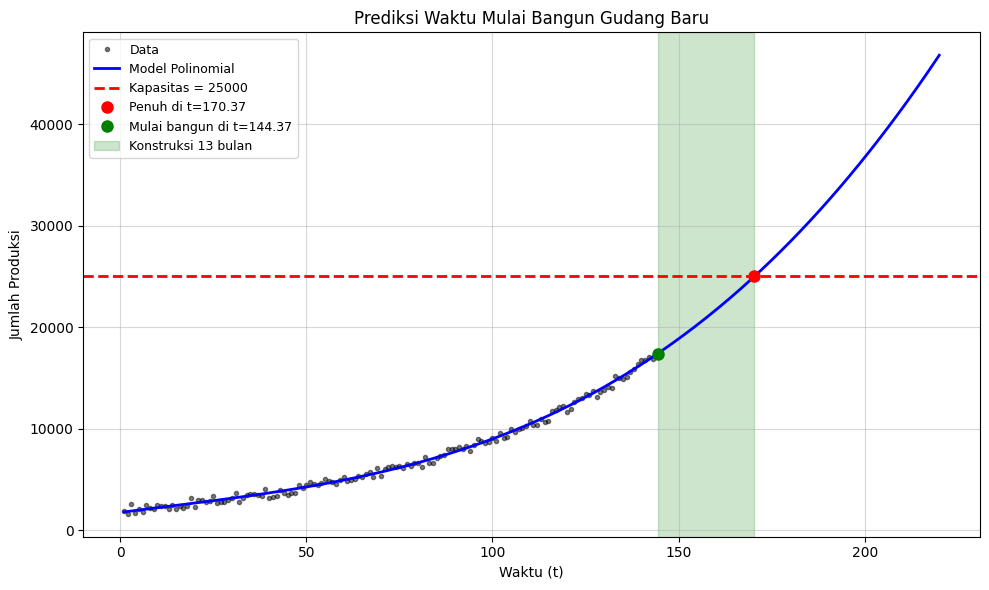

In [6]:
waktu = np.linspace(1, 220, 500)
jumlah_produksi = model_polinomial(waktu)

# 2. Buat grafik
plt.figure(figsize=(10, 6))

plt.plot(x, y, 'k.', label='Data', alpha=0.5)

plt.plot(waktu, jumlah_produksi, 'b-', label='Model Polinomial', linewidth=2)

plt.axhline(y=kapasitas, color='r', linestyle='--', linewidth=2, label=f'Kapasitas = {kapasitas}')

plt.plot(t_hasil, kapasitas, 'ro', markersize=8, label=f'Penuh di t={t_hasil:.2f}')
plt.plot(t_mulai, model_polinomial(t_mulai), 'go', markersize=8, label=f'Mulai bangun di t={t_mulai:.2f}')

plt.axvspan(t_mulai, t_hasil, alpha=0.2, color='green', label=f'Konstruksi {bulan_konstruksi} bulan')

plt.xlabel('Waktu (t)')
plt.ylabel('Jumlah Produksi')
plt.title('Prediksi Waktu Mulai Bangun Gudang Baru')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()